In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [1]:
from google.colab import files
uploaded = files.upload()

Saving House_Price.csv.csv to House_Price.csv.csv


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
data = {
    "SquareFeet": [1500,1800,2400,3000,3500,1200,2000,2700,1600,2200,
                   2800,3100,1400,1700,2500,3300,1900,2600,2100,2900],

    "Bedrooms": [3,4,4,5,5,2,3,4,3,4,
                 4,5,2,3,4,5,3,4,3,5],

    "Bathrooms": [2,2,3,3,4,1,2,3,2,3,
                  3,4,2,2,3,4,2,3,2,4],

    "Price": [300000,360000,450000,550000,650000,220000,400000,500000,320000,430000,
              520000,600000,250000,310000,470000,680000,390000,490000,420000,570000]
}

df = pd.DataFrame(data)

print(df.head())

   SquareFeet  Bedrooms  Bathrooms   Price
0        1500         3          2  300000
1        1800         4          2  360000
2        2400         4          3  450000
3        3000         5          3  550000
4        3500         5          4  650000


In [17]:
print(df.info())
print("\nColumns:")
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   SquareFeet  20 non-null     int64
 1   Bedrooms    20 non-null     int64
 2   Bathrooms   20 non-null     int64
 3   Price       20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes
None

Columns:
Index(['SquareFeet', 'Bedrooms', 'Bathrooms', 'Price'], dtype='object')


In [18]:
X = df[["SquareFeet", "Bedrooms", "Bathrooms"]]
y = df["Price"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16, 3)
Testing data: (4, 3)


In [20]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [21]:
y_pred = model.predict(X_test)

print("Predicted Prices:")
print(y_pred)

Predicted Prices:
[295527.54525988 492876.19233015 623236.32470314 355226.7860619 ]


In [22]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 17221.384076309536
Mean Squared Error : 818293434.5572723
Root Mean Squared Error : 28605.828681533985
R2 Score : 0.9614353609634275


In [23]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(results)

   Actual Price  Predicted Price
0        300000    295527.545260
1        490000    492876.192330
2        680000    623236.324703
3        360000    355226.786062


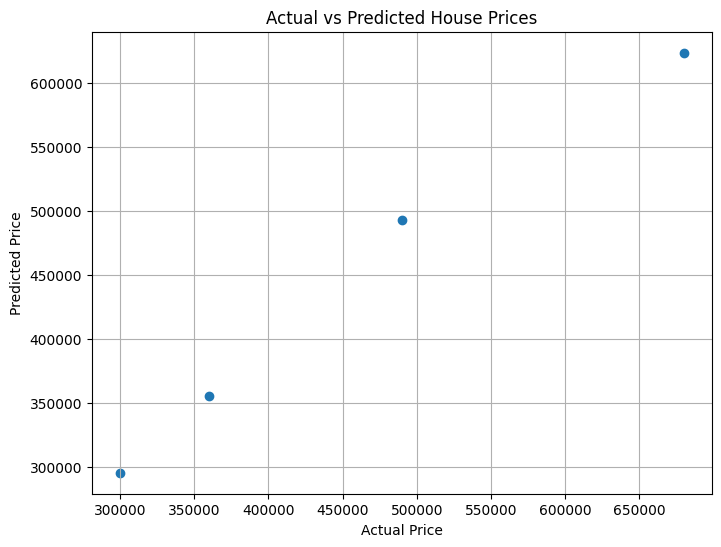

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.show()

In [25]:
new_house = pd.DataFrame({
    "SquareFeet": [2200],
    "Bedrooms": [3],
    "Bathrooms": [2]
})

predicted_price = model.predict(new_house)

print("Predicted House Price = $", round(predicted_price[0],2))

Predicted House Price = $ 412757.45
